# A2 Community Detection 
**Student:** Omar Morales Ortega

---

## Task 1: Community Structure in Stochastic Block Model (SBM) Networks
This notebook analyzes how different community detection algorithms (Louvain, Greedy Modularity, and Infomap) perform as a network transitions from a random state to a clearly defined block structure. We use synthetic networks with N=300 nodes and 5 ground-truth blocks.

Import libraries, define the data directory

In [ ]:

import os
import re
import numpy as np
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from infomap import Infomap
from sklearn.metrics import normalized_mutual_info_score, mutual_info_score
from scipy.stats import entropy
from itertools import combinations

# Configuration
DATA_DIR = "./data/synthetic_networks"  # Ensure this matches your folder name
N_NODES = 300
NODES_PER_BLOCK = 60

plots_dir = "./plots"
os.makedirs(plots_dir, exist_ok=True)

# Ground Truth: [0,0... (60 times), 1,1... (60 times), etc.]
GROUND_TRUTH = np.array([i // NODES_PER_BLOCK for i in range(N_NODES)])


Ground Truth: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4]


---
### Metric Definition
We define the functions to evaluate the partitions. We implement the Pair-based Jaccard Index and the Normalized Variation of Information (NVI), which are standard for community detection comparison.

In [48]:

def calculate_jaccard(labels_true, labels_pred):
    """Computes Jaccard index based on pairs of nodes in the same community."""
    def get_pairs(labels):
        pairs = set()
        for i, j in combinations(range(len(labels)), 2):
            if labels[i] == labels[j]:
                pairs.add(frozenset((i, j)))
        return pairs

    p_true = get_pairs(labels_true)
    p_pred = get_pairs(labels_pred)
    inter = len(p_true.intersection(p_pred))
    union = len(p_true.union(p_pred))
    return inter / union if union > 0 else 0

def calculate_nvi(labels_true, labels_pred):
    """Calculates Normalized Variation of Information: VI / log(N)."""
    n = len(labels_true)
    h_true = entropy(np.bincount(labels_true))
    h_pred = entropy(np.bincount(labels_pred))
    mi = mutual_info_score(labels_true, labels_pred)
    vi = h_true + h_pred - 2 * mi
    return vi / np.log(n) if n > 0 else 0

### Algorithm Implementation
We wrap the three requested algorithms. Louvain and Greedy use modularity maximization, while Infomap uses an information-theoretic approach based on random walks.

In [49]:

def get_louvain_labels(G):
    comms = nx.community.louvain_communities(G, seed=42)
    labels = np.zeros(len(G), dtype=int)
    for idx, c in enumerate(comms):
        for node in c:
            labels[node] = idx
    return labels

def get_greedy_labels(G):
    comms = nx.community.greedy_modularity_communities(G)
    labels = np.zeros(len(G), dtype=int)
    for idx, c in enumerate(comms):
        for node in c:
            labels[node] = idx
    return labels

def get_infomap_labels(G):
    im = Infomap(silent=True)
    mapping = im.add_networkx_graph(G)
    im.run()
    labels = np.zeros(len(G), dtype=int)
    for node in im.tree:
        if node.is_leaf:
            labels[mapping[node.node_id]] = node.module_id - 1
    return labels


def load_sbm_graph(path):
    G = nx.read_pajek(path)
    G = nx.Graph(G)

    mapping = {}
    for node in G.nodes():
        try:
            mapping[node] = int(str(node)) - 1
        except ValueError:
            raise ValueError(f"Unexpected non-integer node label in {path}: {node}")

    G = nx.relabel_nodes(G, mapping)

    # sanity check
    node_set = set(G.nodes())
    if node_set != set(range(len(G))):
        raise ValueError(f"Node relabeling failed; nodes are {sorted(node_set)[:5]}...")

    return G

### Data Processing Loop
We iterate through our files, extracting the $p_{rr}$ value from the filename, running the algorithms, and calculating all requested metrics.

In [50]:
results = []
files = sorted([f for f in os.listdir(DATA_DIR) if f.endswith('.net')])

for f in files:
    prr = float(re.search(r"prr_([0-9.]+)", f).group(1))
    
    G = load_sbm_graph(os.path.join(DATA_DIR, f))
    
    algos = {"Louvain": get_louvain_labels, 
             "Greedy": get_greedy_labels, 
             "Infomap": get_infomap_labels}
    
    for name, func in algos.items():
        labels = func(G)
        partition = [set(np.where(labels == i)[0]) for i in np.unique(labels)]
        
        results.append({
            "prr": prr,
            "Algorithm": name,
            "Q": nx.community.modularity(G, partition),
            "N_Comm": len(partition),
            "NMI": normalized_mutual_info_score(GROUND_TRUTH, labels),
            "Jaccard": calculate_jaccard(GROUND_TRUTH, labels),
            "NVI": calculate_nvi(GROUND_TRUTH, labels)
        })

df = pd.DataFrame(results)

### Evolution Plots
We visualize how the algorithms perform as $p_{rr}$ increases. We look at the detected number of communities, Modularity ($Q$), and similarity to the ground truth (NMI and Jaccard).

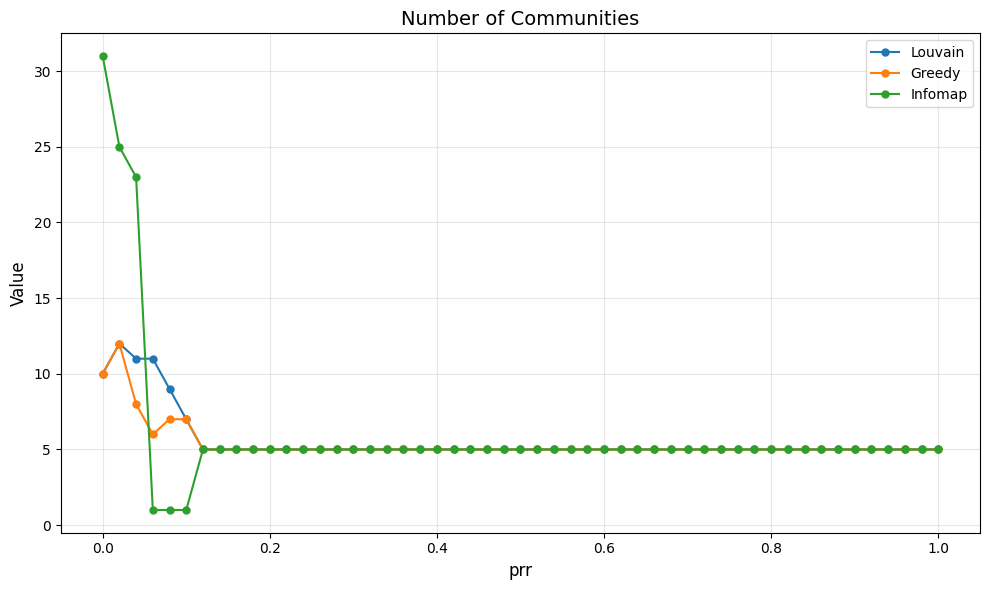

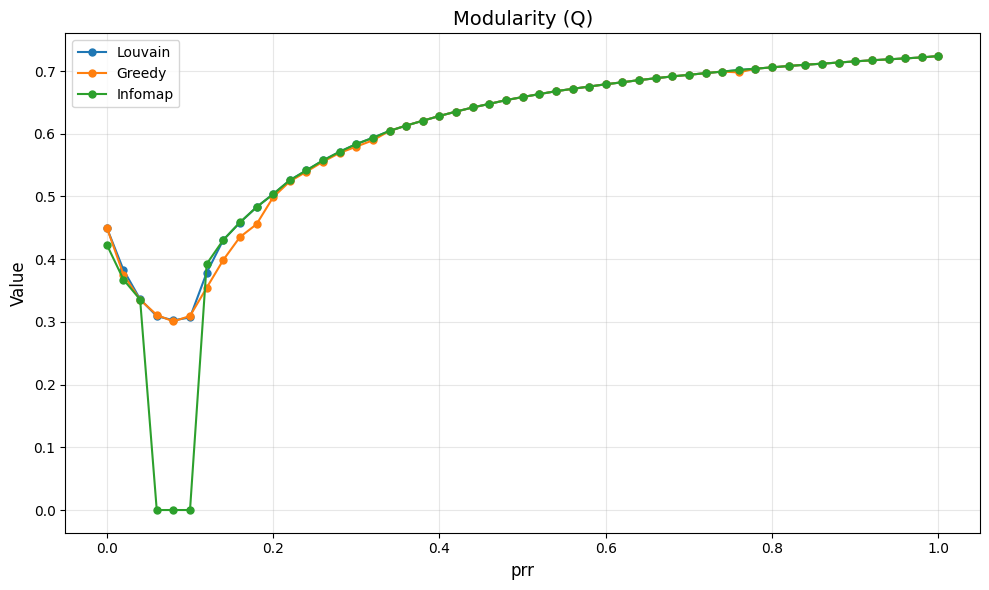

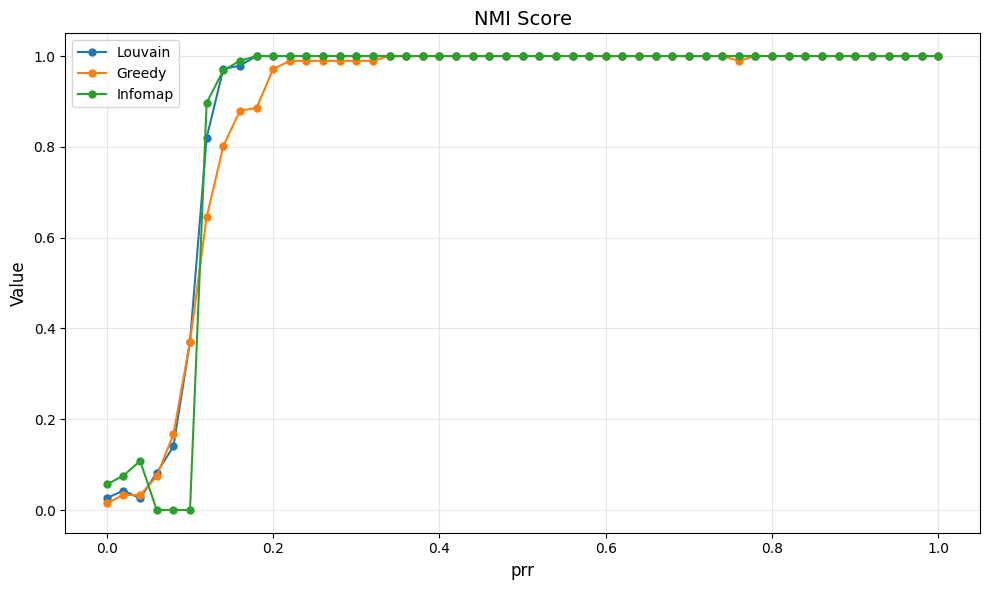

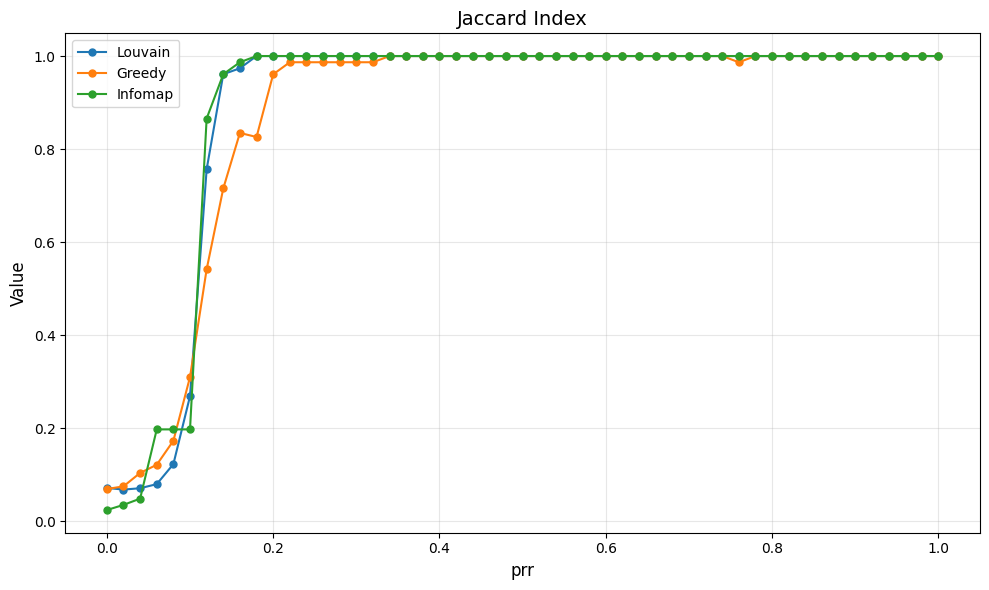

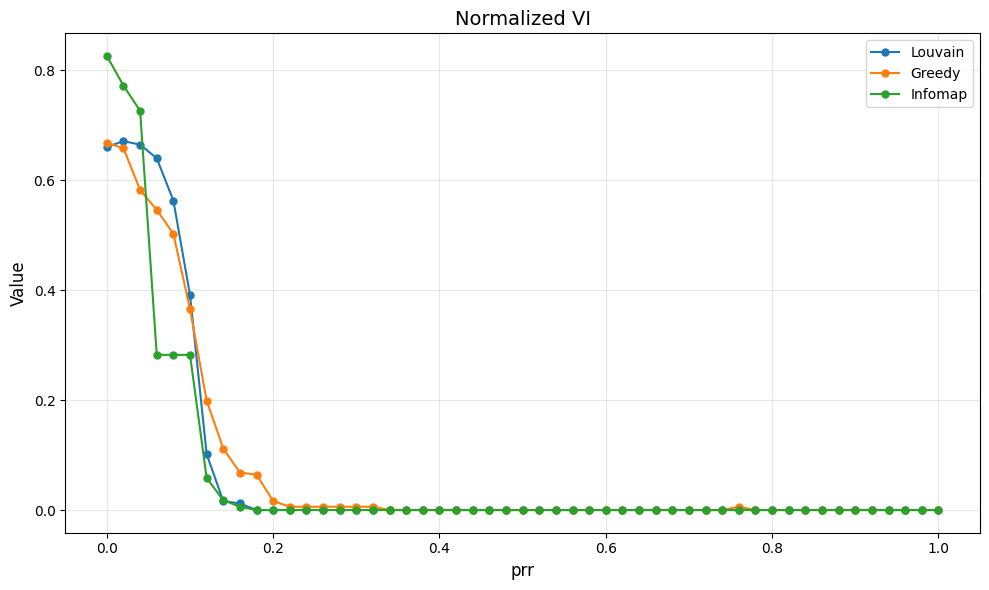

In [ ]:
# Cell Description: Generate individual plots for each metric showing the evolution 
# as a function of prr.

metrics = [("N_Comm", "Number of Communities"), ("Q", "Modularity (Q)"),
           ("NMI", "NMI Score"), ("Jaccard", "Jaccard Index"), ("NVI", "Normalized VI")]

for col, title in metrics:
    fig, ax = plt.subplots(figsize=(10, 6))
    for algo in df['Algorithm'].unique():
        data = df[df['Algorithm'] == algo]
        ax.plot(data['prr'], data[col], label=algo, marker='o', markersize=5)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("prr", fontsize=12)
    ax.set_ylabel("Value", fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    file_name = title.lower().replace(" ", "_").replace("(", "").replace(")", "").replace("$", "").replace("q", "modularity")
    file_path_png = os.path.join(plots_dir, f"{file_name}.png")
    plt.savefig(file_path_png, format="png", bbox_inches="tight")
    plt.show()

### Visualizing Network Snapshots (Fixed Layout)
Finally, we create a color-coded visualization for $p_{rr} = 0.02, 0.16,$ and $1.00$. To make comparison easier, we fix the node positions based on the $p_{rr}=1.00$ network.

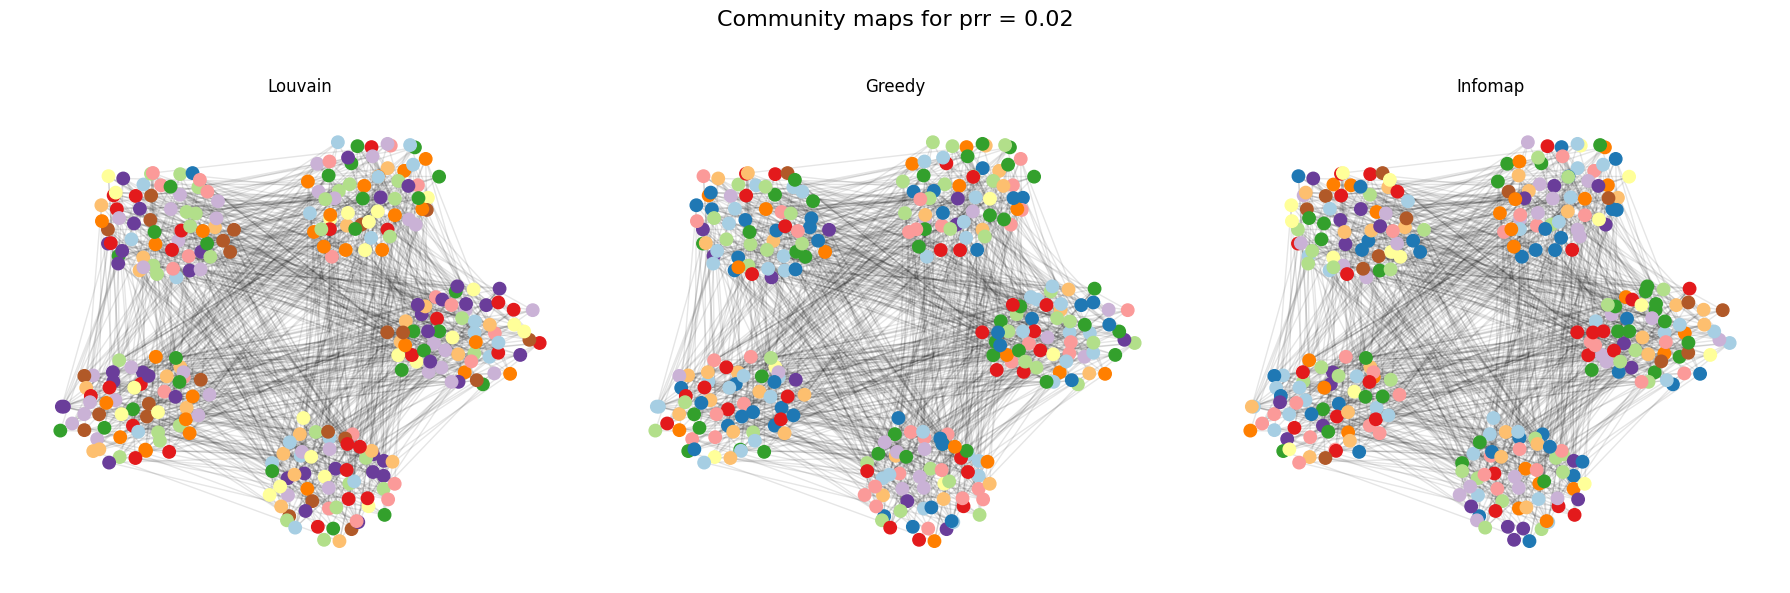

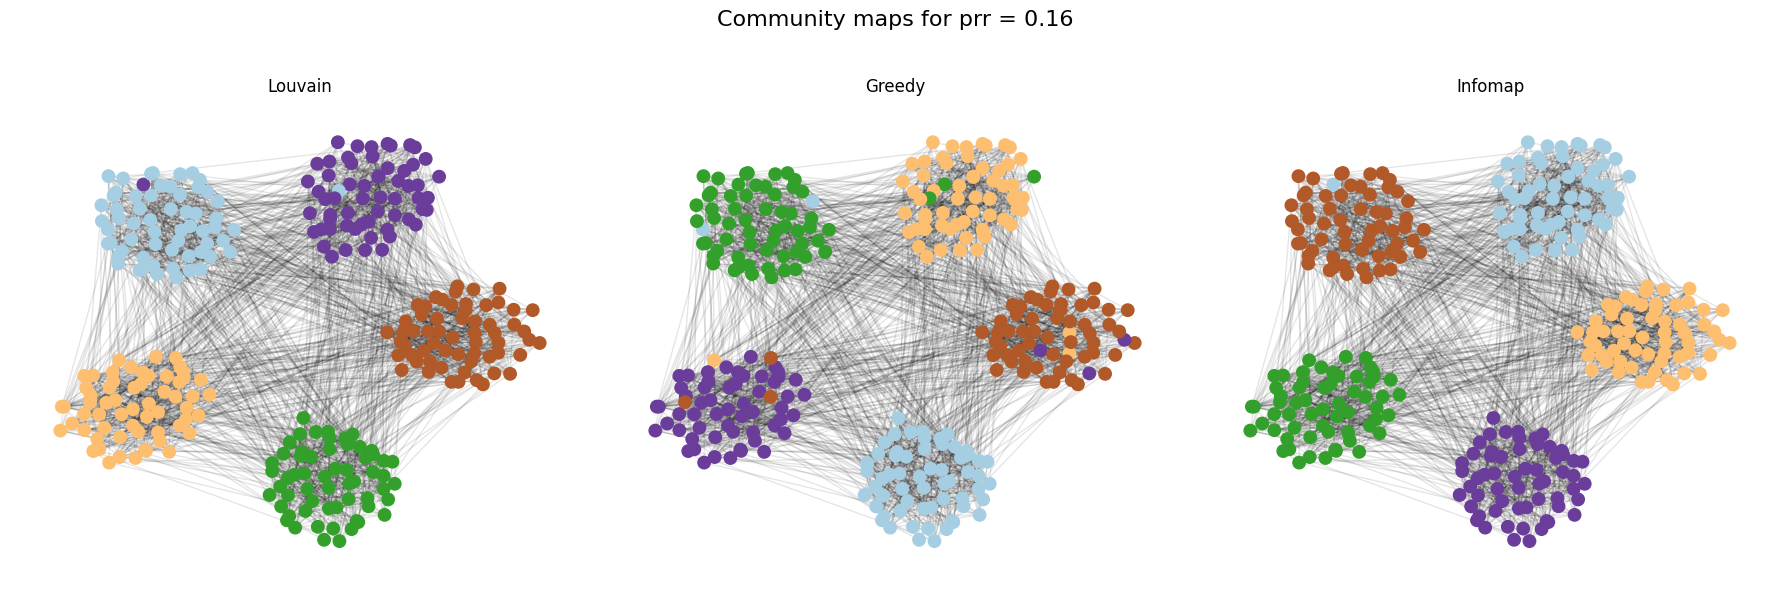

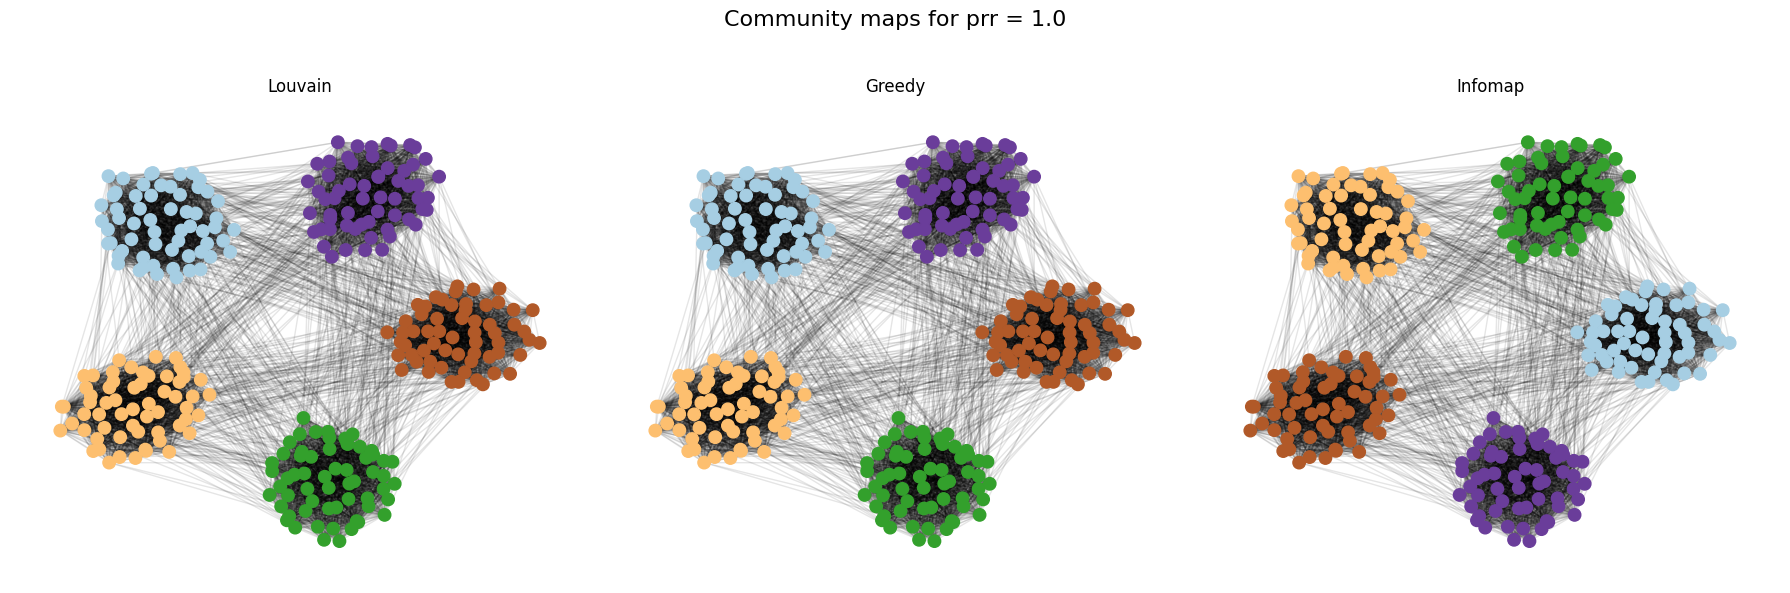

In [ ]:
# Cell Description: Calculate a fixed layout from the densest network 
# and plot the community structure for 3 specific prr values.

# 1. Get positions from the prr=1.00 file
ref_file = "synthetic_network_N_300_blocks_5_prr_1.00_prs_0.02.net"
G_ref = load_sbm_graph(os.path.join(DATA_DIR, ref_file))
fixed_pos = nx.spring_layout(G_ref, seed=42)

# 2. Plot by prr with three algorithms each
algorithms = {
    'Louvain': get_louvain_labels,
    'Greedy': get_greedy_labels,
    'Infomap': get_infomap_labels
}

targets = [0.02, 0.16, 1.00]

for p in targets:
    fig, axs = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True)
    fig.suptitle(f"Community maps for prr = {p}", fontsize=16)

    for ax, (algo_name, algo_func) in zip(axs, algorithms.items()):
        fname = f"synthetic_network_N_300_blocks_5_prr_{p:.2f}_prs_0.02.net"
        G = load_sbm_graph(os.path.join(DATA_DIR, fname))
        labels = algo_func(G)

        ax.set_title(f"{algo_name}")
        nx.draw_networkx_nodes(G, fixed_pos, node_size=80, node_color=labels, cmap='Paired', ax=ax)
        nx.draw_networkx_edges(G, fixed_pos, alpha=0.1, ax=ax)
        ax.axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    file_path_png = os.path.join(plots_dir, f"community_maps_for_prr_{p}.png")
    plt.savefig(file_path_png, format="png", bbox_inches="tight")
    plt.show()

---
## Task 2: Community Structure of Real Networks (Primary School)
In this task, we analyze a real-world social network. We compare how edge weights (interaction time) influence community detection compared to a purely topological approach. We also use school metadata to see if the detected communities correspond to actual school classes.

### Setup
Import libraries and load the weighted network, unweighted network, and node metadata.

In [82]:

from collections import Counter


from collections import defaultdict
import igraph as ig
from cdlib import algorithms



DATA_DIR = "./data/primary_school_network"
file_u = os.path.join(DATA_DIR,"primaryschool_u.net")
file_w = os.path.join(DATA_DIR,"primaryschool_w.net")
file_meta = os.path.join(DATA_DIR,"metadata_primary_school.txt")

def set_color_nodes(communities,G):
    colors=plt.cm.jet(np.linspace(0,1,len(communities))) ## Get the colors for the communities
    community_node={} ## Dictionary to store the community of each node
    count_community=0 ## Counter for the communities' labels

    for community in communities: ## For each community
        for node in community: ## For each node in the community
            community_node[node]=count_community ## Store the label of the community of the node
        count_community=count_community+1 ## Update the counter

    color_nodes=[] ## List to store the color of each node
    for node in G.nodes():  
        color_nodes.append(colors[community_node[node]]) ## Get the color of the node

    return color_nodes


def nx_to_igraph(G_nx):
    G_ig = ig.Graph()
    G_ig.add_vertices(list(map(str, G_nx.nodes())))
    edges = [(str(u), str(v)) for u, v in G_nx.edges()]
    weights = [G_nx[u][v].get("weight", 1.0) for u, v in G_nx.edges()]
    G_ig.add_edges(edges)
    G_ig.es["weight"] = weights
    return G_ig

def run_leiden_igraph(G_nx, weighted=False):
    
    G_ig = nx_to_igraph(G_nx)
    if weighted:
        partition = algorithms.leiden(G_ig, weights="weight").communities
    else:
        partition = algorithms.leiden(G_ig).communities
    return partition

# Load Networks
G_u = nx.read_pajek(file_u)
G_u = nx.Graph(G_u)

G_w = nx.read_pajek(file_w)
G_w = nx.Graph(G_w)

# Load Metadata
metadata = pd.read_csv(file_meta, sep='\s+', skiprows=1, names=['node', 'school_group'])
metadata['node'] = metadata['node'].astype(str)
node_to_group = dict(zip(metadata['node'], metadata['school_group']))
nx.set_node_attributes(G_u, node_to_group, "group")
nx.set_node_attributes(G_w, node_to_group, "group")


### Community Detection
We use Louvain, Greedy Modularity, and Leiden to detect communities. Note that for the weighted network, the algorithms use the actual weights ($w_{ij}$) representing interaction duration.

In [69]:

# 1. Unweighted Detection
comm_u_louvain = nx.community.louvain_communities(G_u, seed=42)
comm_u_greedy = nx.community.greedy_modularity_communities(G_u)
comm_u_leiden = run_leiden_igraph(G_u, weighted=False)


# 2. Weighted Detection
# Assuming the weight attribute in the .net file is named 'weight'
comm_w_louvain = nx.community.louvain_communities(G_w, weight='weight', seed=42)
comm_w_greedy = nx.community.greedy_modularity_communities(G_w, weight='weight')
comm_w_leiden = run_leiden_igraph(G_w, weighted=True)



### Evaluation Metrics
We evaluate all three algorithms on both weighted and unweighted networks. We compare detected communities against the ground truth (school groups) using NMI, Jaccard Index, NVI, and modularity.


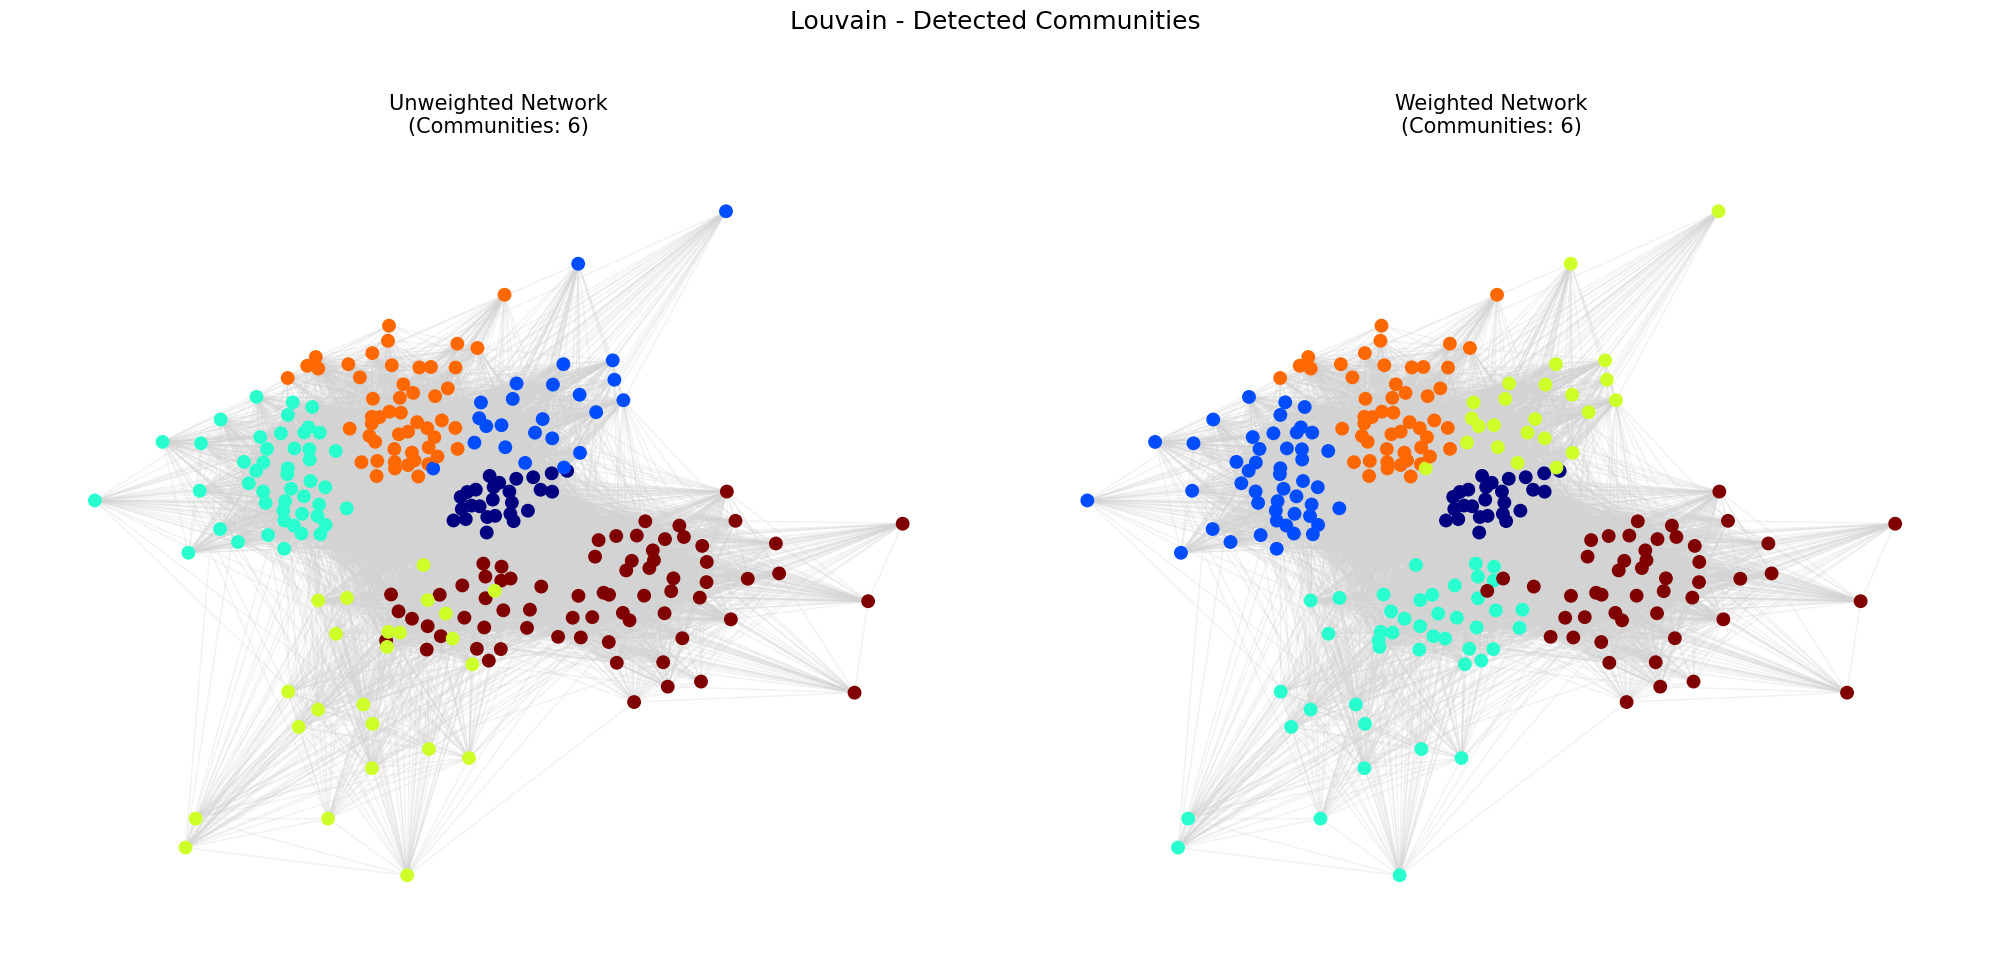

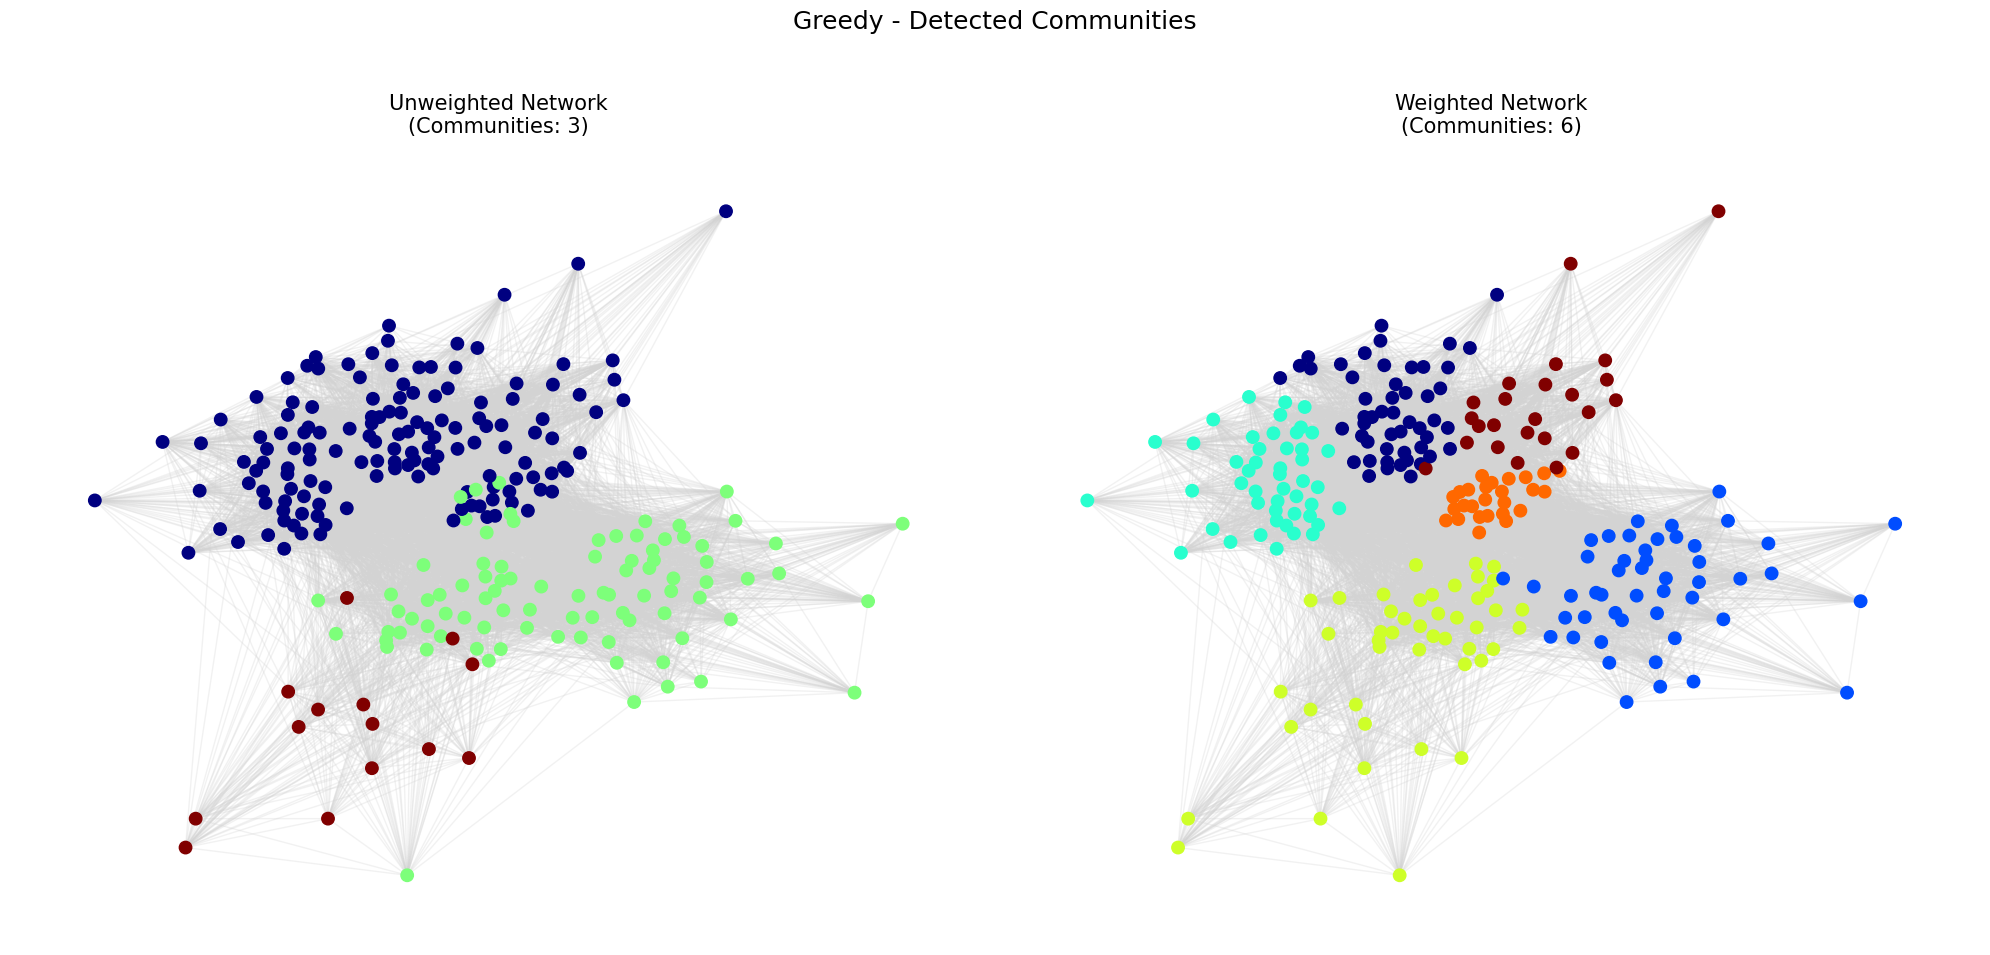

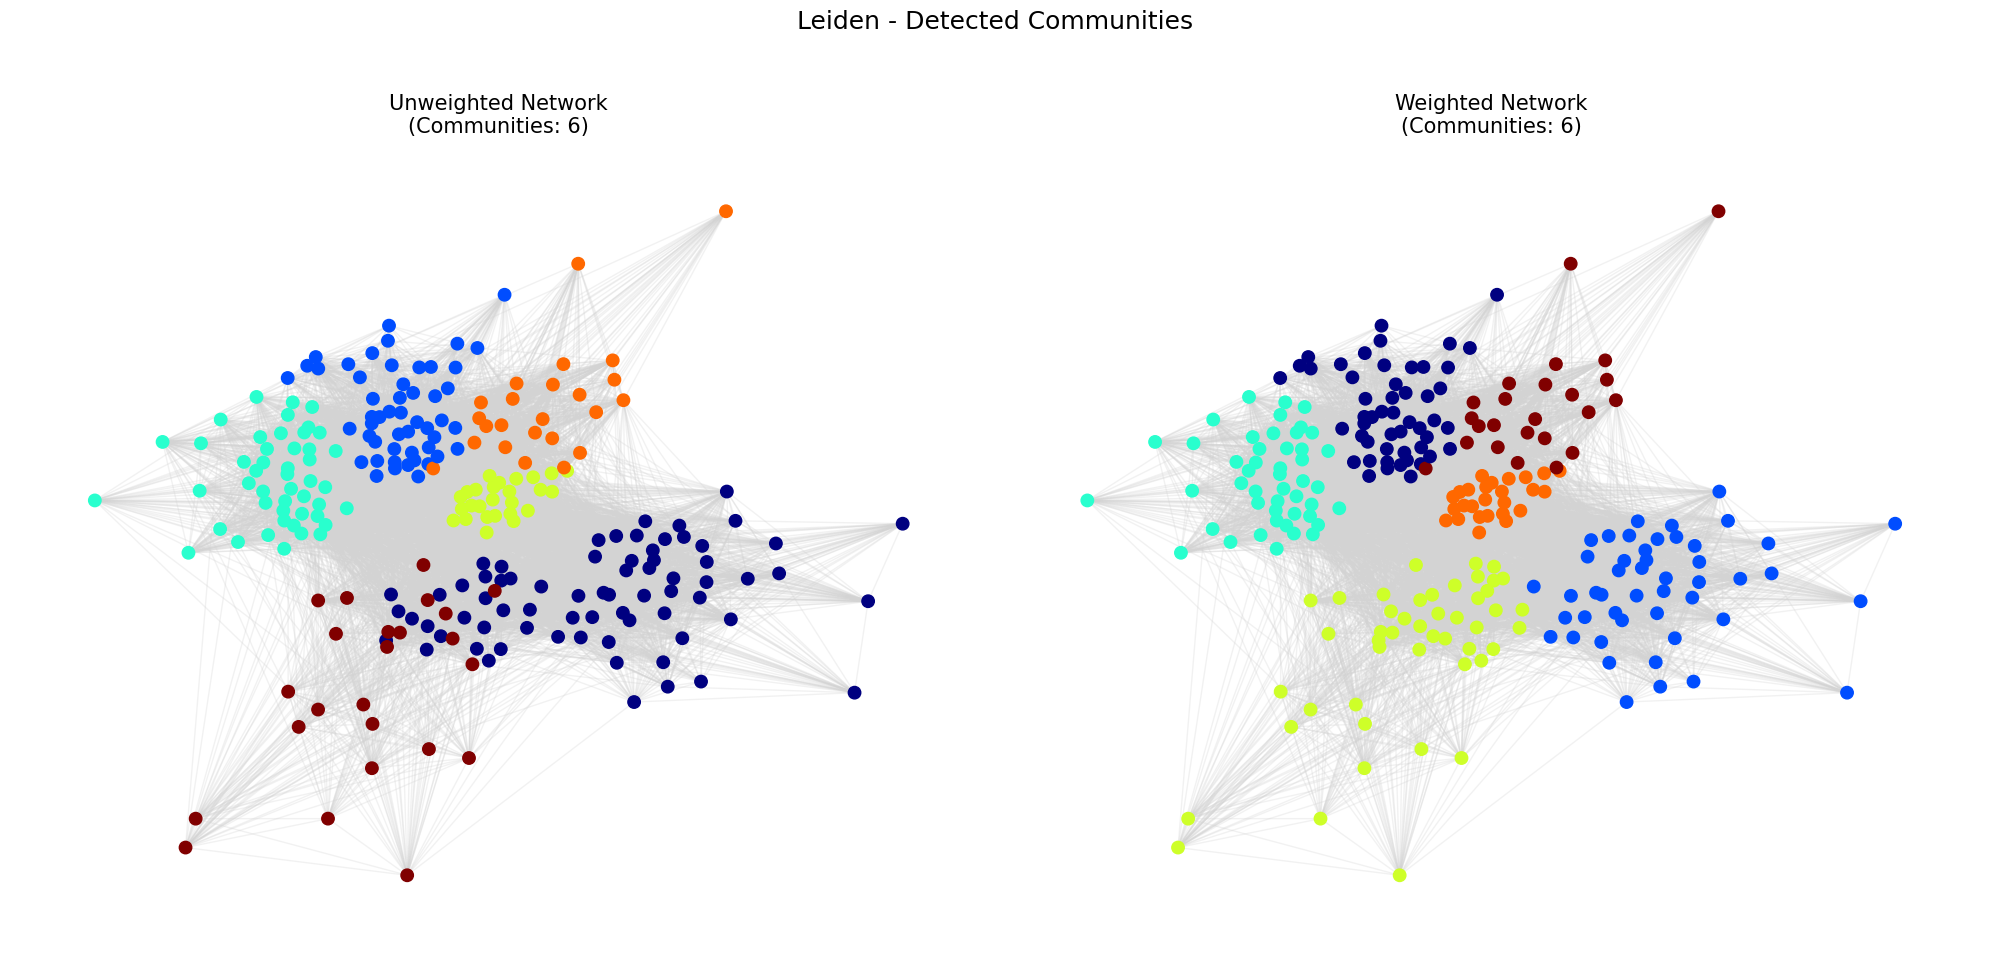

In [ ]:
positions = nx.kamada_kawai_layout(G_w, weight=lambda u, v, d: 1.0 / d.get('weight', 1))

algos = [
    ("Louvain", comm_u_louvain, comm_w_louvain),
    ("Greedy", comm_u_greedy, comm_w_greedy),
    ("Leiden", comm_u_leiden, comm_w_leiden)
]

for name, comms_u, comms_w in algos:
    fig, axs = plt.subplots(1, 2, figsize=(20, 10))
    fig.suptitle(f"{name} - Detected Communities", fontsize=18)

    # Unweighted
    colors_u = set_color_nodes(comms_u, G_u)
    nx.draw_networkx_nodes(G_u, pos=positions, node_color=colors_u, ax=axs[0], node_size=80, cmap='tab20')
    nx.draw_networkx_edges(G_u, pos=positions, ax=axs[0], edge_color='lightgray', alpha=0.3)
    axs[0].set_title(f"Unweighted Network\n(Communities: {len(comms_u)})", fontsize=15)    
    axs[0].axis('off')

    # Weighted
    colors_w = set_color_nodes(comms_w, G_w)
    nx.draw_networkx_nodes(G_w, pos=positions, node_color=colors_w, ax=axs[1], node_size=80, cmap='tab20')
    nx.draw_networkx_edges(G_w, pos=positions, ax=axs[1], edge_color='lightgray', alpha=0.3)
    axs[1].set_title(f"Weighted Network\n(Communities: {len(comms_w)})", fontsize=15)
    axs[1].axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    file_path_png = os.path.join(plots_dir, f"{name.lower()}_detected_communities.png")
    plt.savefig(file_path_png, format="png", bbox_inches="tight")
    plt.show()


### Evaluation Metrics
We evaluate how well a community detection algorithm performs by comparing its detected communities against the known ground-truth labels.

In [80]:

# Extract ground truth labels from metadata
unique_groups = sorted(set(node_to_group.values()))
group_to_id = {group: idx for idx, group in enumerate(unique_groups)}
true_labels = np.array([group_to_id[node_to_group[str(node)]] for node in sorted(G_u.nodes())], dtype=int)

def communities_to_labels(communities, num_nodes):
    """Convert community partitions (list of sets) to label array format.
    
    Handles 1-based indexing from Pajek format by converting to 0-based indices.
    """
    labels = np.zeros(num_nodes, dtype=int)
    for community_id, community in enumerate(communities):
        for node in community:
            node_id = int(node)
            # Pajek uses 1-based indexing; convert to 0-based for array indexing
            if 0 < node_id <= num_nodes:
                labels[node_id - 1] = community_id
    return labels

# Evaluate all algorithms on both weighted and unweighted networks
evaluation_results = []

algorithm_configs = [
    ("Louvain", comm_u_louvain, comm_w_louvain),
    ("Greedy", comm_u_greedy, comm_w_greedy),
    ("Leiden", comm_u_leiden, comm_w_leiden)
]

for algorithm_name, communities_unweighted, communities_weighted in algorithm_configs:
    # Evaluate on unweighted network
    predicted_labels_unweighted = communities_to_labels(communities_unweighted, len(G_u))
    
    nmi_unweighted = normalized_mutual_info_score(true_labels, predicted_labels_unweighted)
    jaccard_unweighted = calculate_jaccard(true_labels, predicted_labels_unweighted)
    nvi_unweighted = calculate_nvi(true_labels, predicted_labels_unweighted)
    modularity_unweighted = nx.community.modularity(G_u, communities_unweighted)
    num_communities_unweighted = len(communities_unweighted)
    
    evaluation_results.append({
        "Algorithm": algorithm_name,
        "Network": "Unweighted",
        "NMI": nmi_unweighted,
        "Jaccard": jaccard_unweighted,
        "NVI": nvi_unweighted,
        "Modularity": modularity_unweighted,
        "Num_Communities": num_communities_unweighted
    })
    
    # Evaluate on weighted network
    predicted_labels_weighted = communities_to_labels(communities_weighted, len(G_w))

    nmi_weighted = normalized_mutual_info_score(true_labels, predicted_labels_weighted)
    jaccard_weighted = calculate_jaccard(true_labels, predicted_labels_weighted)
    nvi_weighted = calculate_nvi(true_labels, predicted_labels_weighted)
    modularity_weighted = nx.community.modularity(G_w, communities_weighted)
    num_communities_weighted = len(communities_weighted)
    
    evaluation_results.append({
        "Algorithm": algorithm_name,
        "Network": "Weighted",
        "NMI": nmi_weighted,
        "Jaccard": jaccard_weighted,
        "NVI": nvi_weighted,
        "Modularity": modularity_weighted,
        "Num_Communities": num_communities_weighted
    })

# Display results
df_task2 = pd.DataFrame(evaluation_results)
print("Task 2: Community Detection Evaluation - Primary School Network")
print("=" * 80)
print(df_task2.to_string(index=False))
print("\n")
print(f"Ground Truth: {len(np.unique(true_labels))} school groups")


Task 2: Community Detection Evaluation - Primary School Network
Algorithm    Network      NMI  Jaccard      NVI  Modularity  Num_Communities
  Louvain Unweighted 0.165669 0.094539 0.620337    0.284035                6
  Louvain   Weighted 0.163099 0.092280 0.629599    0.672732                6
   Greedy Unweighted 0.070849 0.090763 0.545955    0.228380                3
   Greedy   Weighted 0.163897 0.092473 0.629039    0.674246                6
   Leiden Unweighted 0.165669 0.094539 0.620337    0.284035                6
   Leiden   Weighted 0.159822 0.090947 0.632119    0.675513                6


Ground Truth: 11 school groups


### Composition Analysis (Stacked Bar Plots)
We analyze the "purity" of the detected communities. A stacked bar plot shows how many students from each class (4A, 3B, etc.) are grouped together in each community.

Purity for Community 0 in Louvain - Unweighted: 96.15%
Purity for Community 1 in Louvain - Unweighted: 95.83%
Purity for Community 2 in Louvain - Unweighted: 48.94%
Purity for Community 3 in Louvain - Unweighted: 95.83%
Purity for Community 4 in Louvain - Unweighted: 50.98%
Purity for Community 5 in Louvain - Unweighted: 34.29%
Overall Purity for Louvain - Unweighted: 59.50%



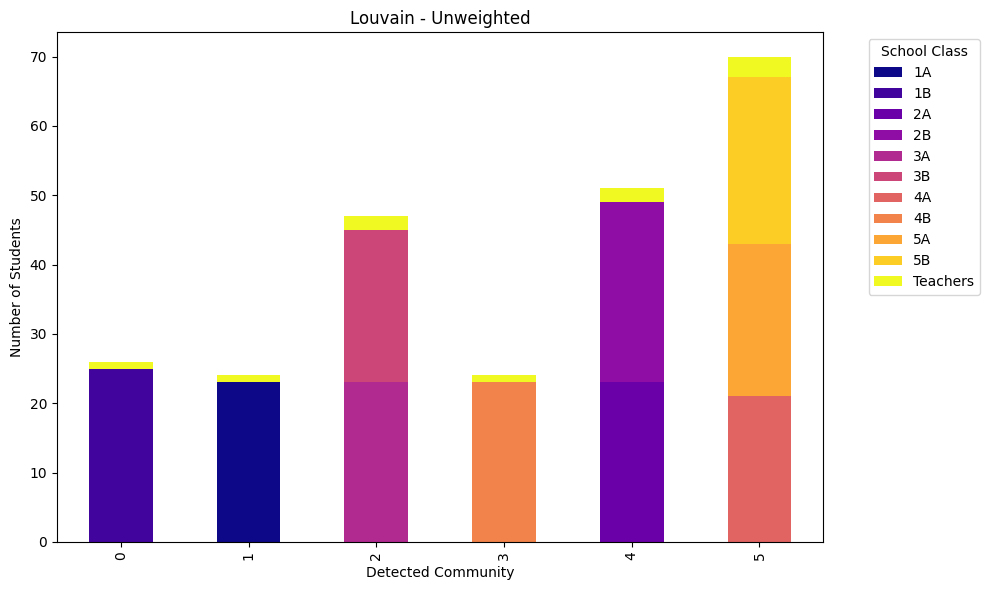

Purity for Community 0 in Louvain - Weighted: 96.15%
Purity for Community 1 in Louvain - Weighted: 48.94%
Purity for Community 2 in Louvain - Weighted: 48.89%
Purity for Community 3 in Louvain - Weighted: 95.83%
Purity for Community 4 in Louvain - Weighted: 50.98%
Purity for Community 5 in Louvain - Weighted: 48.98%
Overall Purity for Louvain - Weighted: 59.09%



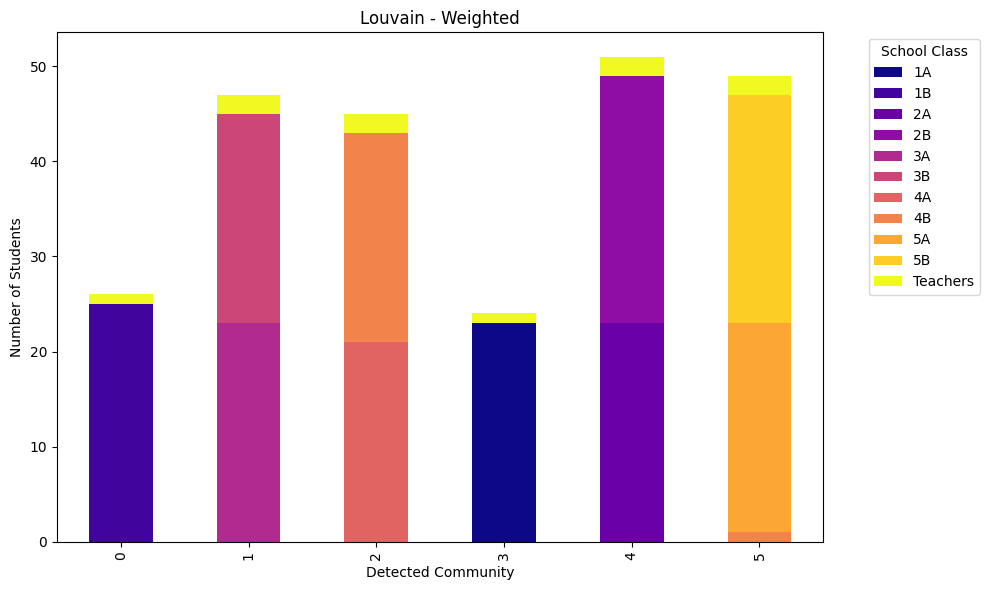

Purity for Community 0 in Greedy - Unweighted: 18.44%
Purity for Community 1 in Greedy - Unweighted: 27.59%
Purity for Community 2 in Greedy - Unweighted: 100.00%
Overall Purity for Greedy - Unweighted: 26.45%



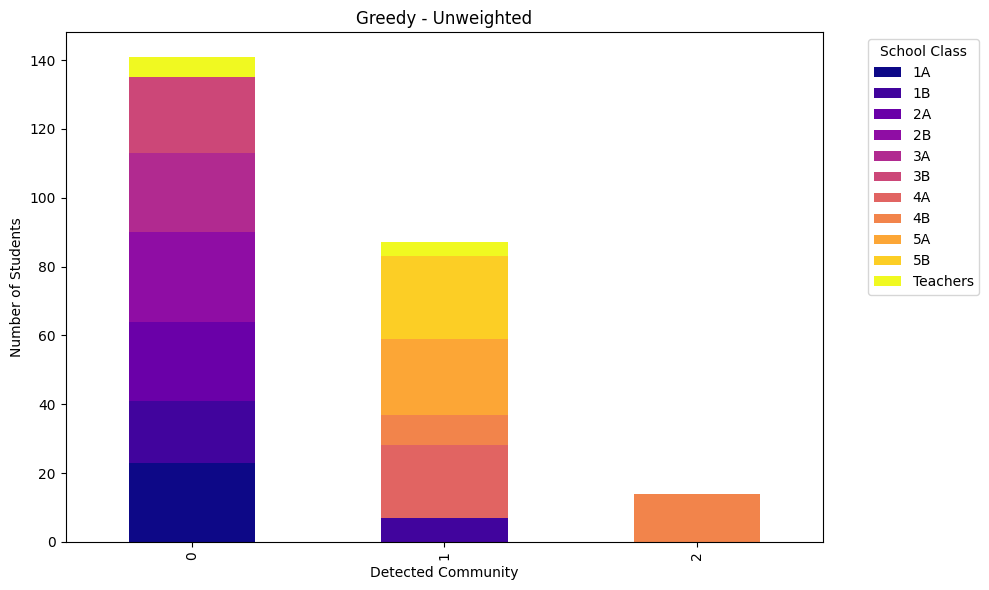

Purity for Community 0 in Greedy - Weighted: 50.98%
Purity for Community 1 in Greedy - Weighted: 50.00%
Purity for Community 2 in Greedy - Weighted: 48.94%
Purity for Community 3 in Greedy - Weighted: 50.00%
Purity for Community 4 in Greedy - Weighted: 96.15%
Purity for Community 5 in Greedy - Weighted: 95.83%
Overall Purity for Greedy - Weighted: 59.50%



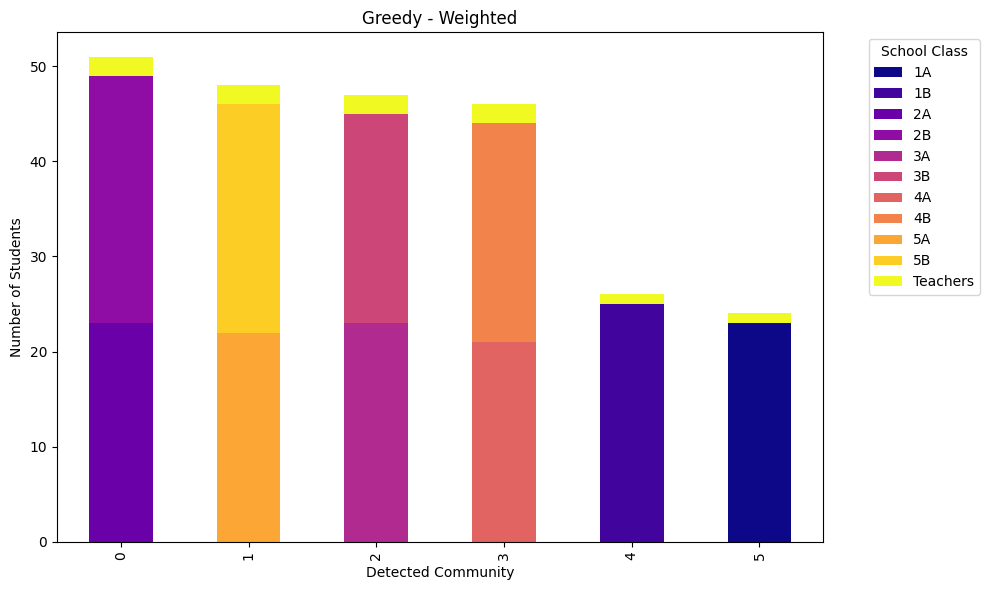

Purity for Community 0 in Leiden - Unweighted: 34.29%
Purity for Community 1 in Leiden - Unweighted: 50.98%
Purity for Community 2 in Leiden - Unweighted: 48.94%
Purity for Community 3 in Leiden - Unweighted: 96.15%
Purity for Community 4 in Leiden - Unweighted: 95.83%
Purity for Community 5 in Leiden - Unweighted: 95.83%
Overall Purity for Leiden - Unweighted: 59.50%



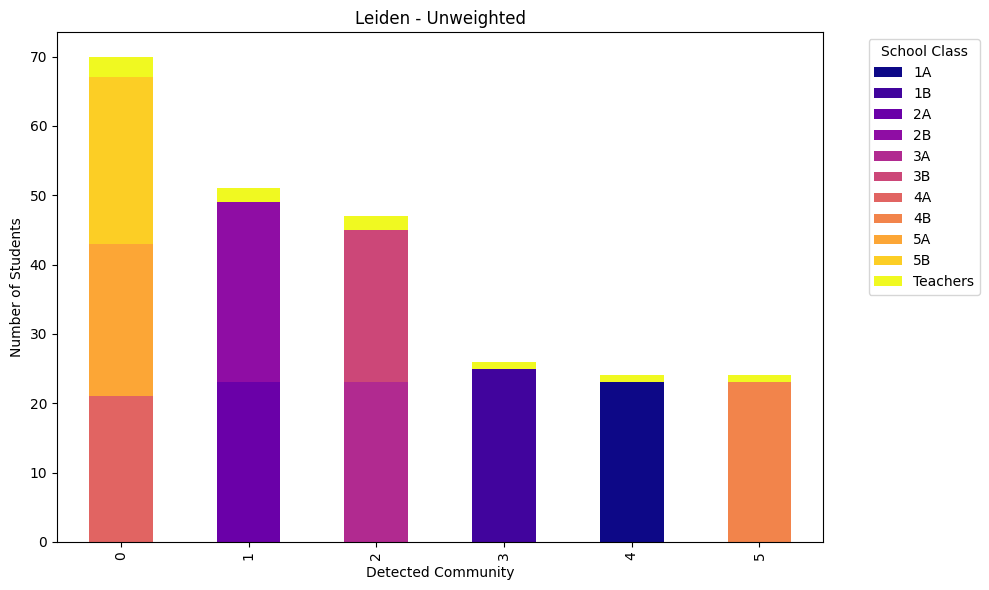

Purity for Community 0 in Leiden - Weighted: 50.98%
Purity for Community 1 in Leiden - Weighted: 48.94%
Purity for Community 2 in Leiden - Weighted: 48.94%
Purity for Community 3 in Leiden - Weighted: 48.94%
Purity for Community 4 in Leiden - Weighted: 96.15%
Purity for Community 5 in Leiden - Weighted: 95.83%
Overall Purity for Leiden - Weighted: 59.09%



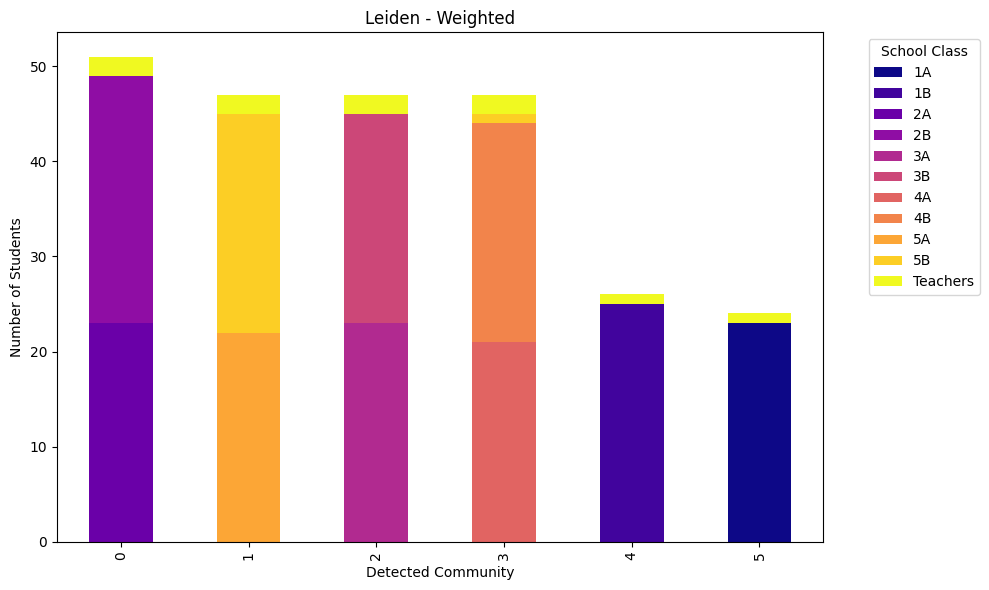

In [ ]:
def visualize_community_groups(communities, graph, plot_title):
    from collections import defaultdict
    data_points = []
    total_majority = 0
    total_nodes = 0
    for idx, comm in enumerate(communities):
        class_distribution = defaultdict(int)
        for n in comm:
            cls = graph.nodes[n].get("group", "Unknown")
            class_distribution[cls] += 1
        # Compute purity percentage
        majority_class = max(class_distribution.values()) if class_distribution else 0
        comm_size = sum(class_distribution.values())
        purity = (majority_class / comm_size) if comm_size > 0 else 0
        print(f"Purity for Community {idx} in {plot_title}: {purity:.2%}")

        total_majority += majority_class
        total_nodes += comm_size

        for cls, cnt in class_distribution.items():
            data_points.append({"Community": idx, "Class": cls, "Count": cnt})

    overall_purity = (total_majority / total_nodes) if total_nodes > 0 else 0
    print(f"Overall Purity for {plot_title}: {overall_purity:.2%}\n")

    df = pd.DataFrame(data_points)
    df_pivot = df.pivot(index="Community", columns="Class", values="Count").fillna(0)
    df_pivot.plot(kind="bar", stacked=True, colormap="plasma", figsize=(10, 6))
    plt.title(plot_title)
    plt.ylabel("Number of Students")
    plt.xlabel("Detected Community")
    plt.legend(title="School Class", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    file_path_png = os.path.join(plots_dir, f"{plot_title.lower().replace(' ', '_').replace('-', '_')}_groups.png")
    plt.savefig(file_path_png, format="png", bbox_inches="tight")
    plt.show()

for algo_name, unweighted_comms, weighted_comms in algos:
    visualize_community_groups(unweighted_comms, G_u, f"{algo_name} - Unweighted")
    visualize_community_groups(weighted_comms, G_w, f"{algo_name} - Weighted")